In [2]:
import numpy as np
import pandas as pd

In [3]:
data=pd.read_csv("/content/insurance2.csv")

In [4]:
data.head()

,age,sex,bmi,children,smoker,region,charges,insuranceclaim
0,19,0,27.900,0,1,3,16884.92400,1
1,18,1,33.770,1,0,2,1725.55230,1
2,28,1,33.000,3,0,2,4449.46200,0
3,33,1,22.705,0,0,1,21984.47061,0
4,32,1,28.880,0,0,1,3866.85520,1


In [5]:
data.tail()

,age,sex,bmi,children,smoker,region,charges,insuranceclaim
1333,50,1,30.97,3,0,1,10600.5483,0
1334,18,0,31.92,0,0,0,2205.9808,1
1335,18,0,36.85,0,0,2,1629.8335,1
1336,21,0,25.80,0,0,3,2007.9450,0
1337,61,0,29.07,0,1,1,29141.3603,1


In [6]:
data.shape

(1338, 8)

In [7]:
data.columns.to_list()

['age',
 'sex',
 'bmi',
 'children',
 'smoker',
 'region',
 'charges',
 'insuranceclaim']

In [8]:
data.dtypes

,0
age,int64
sex,int64
bmi,float64
children,int64
smoker,int64
region,int64
charges,float64
insuranceclaim,int64


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             1338 non-null   int64  
 1   sex             1338 non-null   int64  
 2   bmi             1338 non-null   float64
 3   children        1338 non-null   int64  
 4   smoker          1338 non-null   int64  
 5   region          1338 non-null   int64  
 6   charges         1338 non-null   float64
 7   insuranceclaim  1338 non-null   int64  
dtypes: float64(2), int64(6)
memory usage: 83.8 KB


In [10]:
data.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0
insuranceclaim,0


In [11]:
numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns.to_list()
print("Numerical Variables:", numerical_cols)

Numerical Variables: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges', 'insuranceclaim']


In [12]:
categorical_cols = data.select_dtypes(include=['object']).columns.to_list()
print("Categorical Variables:", categorical_cols)

Categorical Variables: []


In [13]:
print(data['insuranceclaim'].value_counts())

insuranceclaim
1    783
0    555
Name: count, dtype: int64


In [14]:
print(data['insuranceclaim'].value_counts(normalize=True)*100)

insuranceclaim
1    58.520179
0    41.479821
Name: proportion, dtype: float64


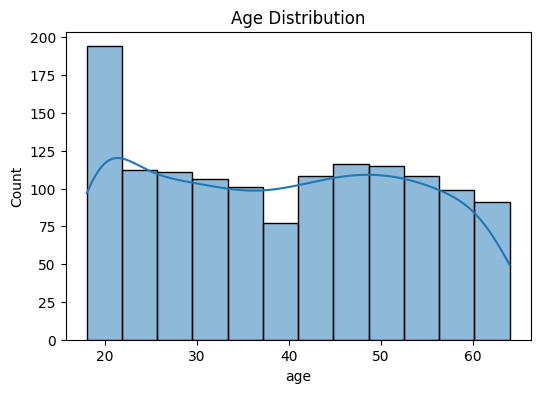

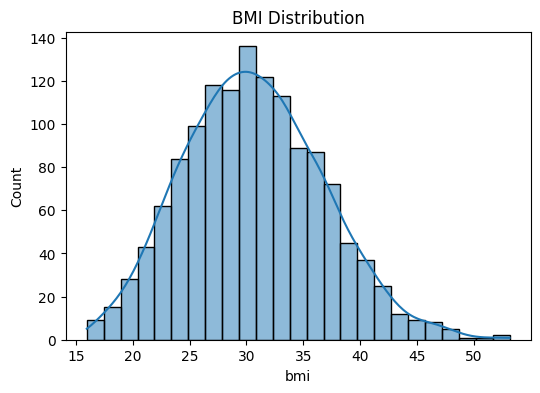

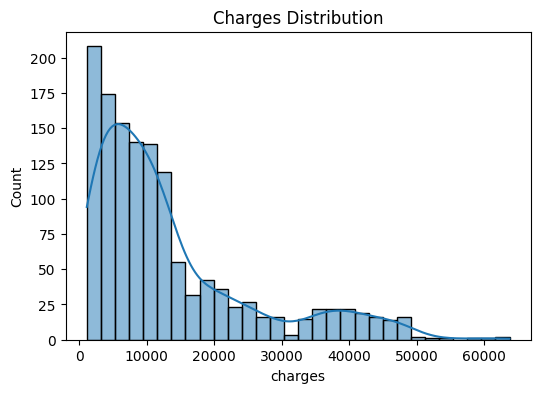

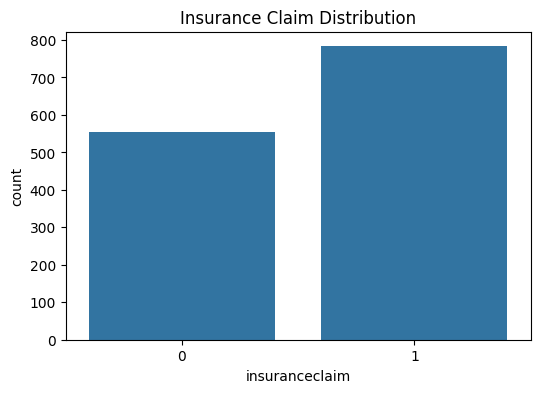

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Age Distribution
plt.figure(figsize=(6,4))
sns.histplot(data['age'], kde=True)
plt.title("Age Distribution")
plt.show()

# BMI Distribution
plt.figure(figsize=(6,4))
sns.histplot(data['bmi'], kde=True)
plt.title("BMI Distribution")
plt.show()

# Charges Distribution
plt.figure(figsize=(6,4))
sns.histplot(data['charges'], kde=True)
plt.title("Charges Distribution")
plt.show()

# Insurance Claim Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='insuranceclaim', data=data)
plt.title("Insurance Claim Distribution")
plt.show()

In [16]:
#divide the data into dependent and independent colums
x=data.drop(['insuranceclaim'],axis=1) #stores the independent columnns
y=data['insuranceclaim'] #stores the dependent or the target column

In [18]:
x.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


In [19]:
y.head()

,insuranceclaim
0,1
1,1
2,0
3,0
4,1


In [20]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25)

In [21]:
#Feature scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numeric_cols = ['age', 'bmi', 'children', 'charges']

x_train_scaled = x_train.copy()
x_test_scaled = x_test.copy()

x_train_scaled[numeric_cols] = scaler.fit_transform(x_train[numeric_cols])

x_test_scaled[numeric_cols] = scaler.transform(x_test[numeric_cols])

In [22]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()

In [23]:
# Train Model
model.fit(x_train_scaled, y_train)

LogisticRegression()

In [24]:
# Predictions
y_pred = model.predict(x_test_scaled)

In [29]:
# Prediction Probabilities
y_prob = model.predict_proba(x_test_scaled)[:,1]

In [30]:
print(y_prob)

[0.4045172  0.60600748 0.99432152 0.24861785 0.68719639 0.01210488
 0.99101379 0.0849913  0.88620498 0.26228088 0.47451334 0.27307872
 0.94356131 0.69349654 0.36058544 0.88976117 0.81348233 0.90488691
 0.18672619 0.29919903 0.0455996  0.98326694 0.58366481 0.89697633
 0.05625675 0.98077534 0.15335849 0.40020446 0.88265638 0.02888903
 0.11944044 0.91637999 0.7015547  0.43708148 0.1150859  0.9204803
 0.97807669 0.33772255 0.9747846  0.08250381 0.03747138 0.34818938
 0.26343755 0.26459739 0.95267055 0.44033034 0.45878234 0.89832342
 0.06754755 0.05467227 0.06207015 0.01302947 0.99423631 0.55485137
 0.82778803 0.79226482 0.79665654 0.47984822 0.57067334 0.11547351
 0.64254753 0.99502235 0.96421769 0.99039605 0.72080836 0.49018066
 0.98726715 0.99605454 0.71516383 0.08768721 0.79252655 0.99954197
 0.01624355 0.31328517 0.47550199 0.44459764 0.99807822 0.83349053
 0.99976217 0.46477531 0.6198455  0.37019691 0.82896506 0.9933794
 0.97890853 0.78264312 0.45646    0.80475596 0.80015923 0.938796

In [31]:
#Testing the accuracy of the model
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.8895522388059701


In [32]:
from sklearn.metrics import classification_report, confusion_matrix

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))


Confusion Matrix
[[125  16]
 [ 21 173]]

Classification Report
              precision    recall  f1-score   support

           0       0.86      0.89      0.87       141
           1       0.92      0.89      0.90       194

    accuracy                           0.89       335
   macro avg       0.89      0.89      0.89       335
weighted avg       0.89      0.89      0.89       335



In [33]:
#Building the same solution using ANN

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [75]:
model=keras.Sequential([
    layers.Input(shape=(x_train_scaled.shape[1],),name='input_layer'), #input_layer has 7 neurons
    layers.Dense(32,activation='relu',name='hidden_layer_1'), #hidden_layer_1 has 32 neurons
    layers.Dense(16,activation='relu',name='hidden_layer_2'), #hidden_layer_2 has 16 neurons
    layers.Dense(1,activation='sigmoid',name='output_layer') #output_layer has just 1 neuron since it is a binary classifier
])

In [76]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Epoch 1/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9227 - loss: 0.2384 - val_accuracy: 0.8905 - val_loss: 0.2584
Epoch 2/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9177 - loss: 0.2336 - val_accuracy: 0.9005 - val_loss: 0.2538
Epoch 3/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9165 - loss: 0.2307 - val_accuracy: 0.8905 - val_loss: 0.2560
Epoch 4/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9202 - loss: 0.2278 - val_accuracy: 0.9005 - val_loss: 0.2511
Epoch 5/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9202 - loss: 0.2260 - val_accuracy: 0.9005 - val_loss: 0.2486
Epoch 6/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9177 - loss: 0.2228 - val_accuracy: 0.8955 - val_loss: 0.2480
Epoch 7/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9202 - loss: 0.2217 - val_accuracy: 0.8905 - val_loss: 0.2516
Epoch 8/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9202 - loss: 0.2193 - val_accuracy: 0.9005 - v

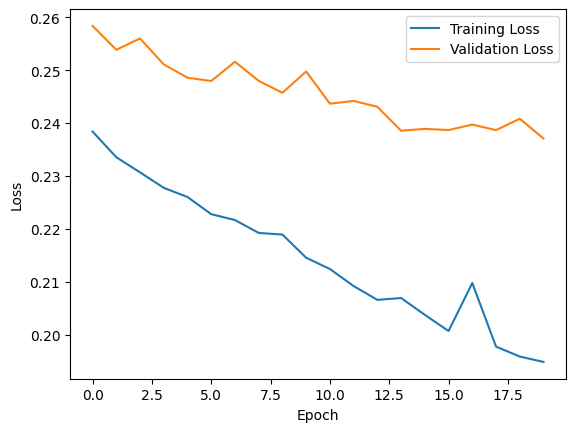

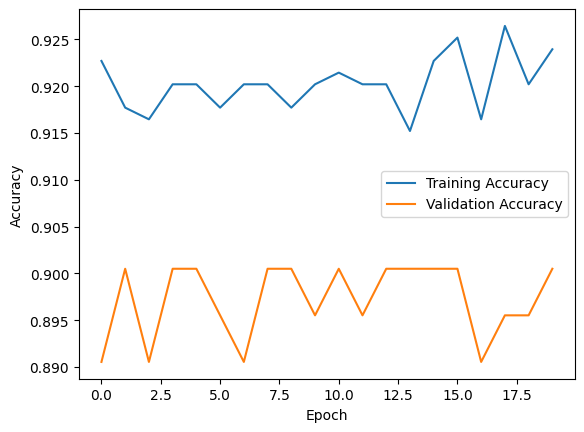

In [84]:
#Plot training history
import matplotlib.pyplot as plt

history = model.fit(x_train_scaled, y_train, epochs=20, batch_size=32, validation_split=0.2)

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

**If training accuracy continues increasing while validation accuracy begins to decline, what does this indicate?**

It indicates overfitting.

The model is learning the training data too specifically, including noise and patterns that do not generalize to new data. As a result, performance on unseen validation data worsens even though performance on the training data continues to improve.

Common remedies for overfitting:

1.Use Early Stopping
2.Add Dropout layers

In [85]:
y_prob=model.predict(x_test_scaled)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [86]:
y_pred = (y_prob > 0.5).astype(int)

In [87]:
#Evaluate the model
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9194029850746268


In [88]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[133   8]
 [ 19 175]]


In [89]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.94      0.91       141
           1       0.96      0.90      0.93       194

    accuracy                           0.92       335
   macro avg       0.92      0.92      0.92       335
weighted avg       0.92      0.92      0.92       335



An Artificial Neural Network (ANN) was developed to predict whether a customer is likely to make an insurance claim. The dataset was split into training and testing sets, and feature scaling was performed using StandardScaler. The neural network consisted of multiple hidden layers with ReLU activation functions and a Sigmoid output layer for binary classification. The model was trained using the Adam optimizer and Binary Crossentropy loss function. Model performance was evaluated using accuracy, confusion matrix, and classification metrics on the test dataset.

In [93]:
#LANGCHAIN + RAG
!pip install langchain langchain-community langchain-google-genai langchain-text-splitters pypdf faiss-cpu

  Using cached langchain_community-0.4.2-py3-none-any.whl.metadata (3.4 kB)
  Using cached langchain_google_genai-4.3.4-py3-none-any.whl.metadata (2.7 kB)
  Using cached langchain_text_splitters-1.1.2-py3-none-any.whl.metadata (3.3 kB)
  Using cached pypdf-6.16.1-py3-none-any.whl.metadata (7.5 kB)
  Using cached faiss_cpu-1.15.0-cp310-abi3-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (7.8 kB)
  Using cached httpx_sse-0.4.3-py3-none-any.whl.metadata (9.7 kB)
  Using cached langchain_classic-1.0.8-py3-none-any.whl.metadata (5.1 kB)
  Using cached pydantic_settings-2.15.0-py3-none-any.whl.metadata (3.9 kB)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached filetype-1.2.0-py2.py3-none-any.whl.metadata (6.5 kB)
  Using cached langchain_core-1.5.5-py3-none-any.whl.metadata (4.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.3/73.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━

In [1]:
import os
from langchain_community.document_loaders import PyPDFLoader
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

/tmp/ipykernel_28710/1183458277.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


In [3]:
#load pdf
loader = PyPDFLoader("/content/M&A Playbook_ Comprehensive Guide to Deals and Integration.pdf")
documents=loader.load()

report=""
for page in documents:
  report += page.page_content+'\n'

print("Total pages:", len(documents))
print("First page:", documents[0].page_content + '\n')
print("Report", report[:1000])

Total pages: 25
First page: M&A Playbook: Comprehensive Guide to Deals and
Integration
Executive Summary
Purpose: This playbook provides a step-by-step guide through a merger and acquisition (M&A)
transaction, from initial confidentiality agreements through valuation, risk management, legal
agreements, and post-merger integration. It is designed for both business leaders and technical
practitioners, blending strategic insights with practical examples. 
Sample Clauses: It includes professionally formatted sample clauses for key deal documents – 
Confidentiality (NDA), Representations & Warranties, Indemnification, Termination, etc. – with
explanations of their purpose and realistic language examples. 
Valuation Methods: The guide covers common valuation techniques, including the Enterprise
Value/EBITDA multiple approach and Discounted Cash Flow (DCF) analysis, with mock calculations
to illustrate how a target company might be valued in practice. 
Risk Checklists: We provide due diligenc

In [5]:
#chunk the document
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)

chunks = text_splitter.split_documents(documents)

print("Total Chunks:", len(chunks))
print(chunks[0].page_content)

Total Chunks: 96
M&A Playbook: Comprehensive Guide to Deals and
Integration
Executive Summary
Purpose: This playbook provides a step-by-step guide through a merger and acquisition (M&A)
transaction, from initial confidentiality agreements through valuation, risk management, legal
agreements, and post-merger integration. It is designed for both business leaders and technical
practitioners, blending strategic insights with practical examples. 
Sample Clauses: It includes professionally formatted sample clauses for key deal documents – 
Confidentiality (NDA), Representations & Warranties, Indemnification, Termination, etc. – with
explanations of their purpose and realistic language examples. 
Valuation Methods: The guide covers common valuation techniques, including the Enterprise
Value/EBITDA multiple approach and Discounted Cash Flow (DCF) analysis, with mock calculations
to illustrate how a target company might be valued in practice.


1. **Why is document chunking required?**
  Chunking breaks a large document into smaller meaningful sections that can fit within embedding model
  and LLM context limits. It also improves retrieval accuracy because only the most relevant chunks are
  searched and supplied to the LLM.

2. **What happens if chunks are too small?**
  Important context may be split across chunks.
  Retrieval may return incomplete information.
  Answer quality can decrease because related information is separated.

  Example:

    Chunk A:
    Due diligence includes financial review.

    Chunk B:
    Legal review and operational review.

    A query about due diligence may retrieve only one partial chunk.

3. **What happens if chunks are too large?**
  Irrelevant information gets mixed with relevant information.
  Retrieval precision decreases.
  More tokens are consumed.
  Embedding quality may degrade.

4. **How did you select your chunk size?**
  Typical experimentation:


---


    Chunk Size	Overlap	  Observation
    500	        100	      Context often fragmented
    1000	    200	      Good balance
    1500	    300	      Retrieval became less precise


In [7]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings

In [ ]:
os.environ["GOOGLE_API_KEY"] = ""
embedding = GoogleGenerativeAIEmbeddings(
    model="gemini-embedding-001"
)

1. **What is an embedding?**
  An embedding is a numerical vector representation of text that captures semantic meaning.

2. **Why are embeddings required for RAG?**
  Embeddings allow text to be compared based on meaning rather than exact keyword matching.

3. **How does semantic similarity work in the retrieval process?**


    *   User question is converted into an embedding.
    *   Stored document chunks already have embeddings.
    *   Similarity scores are calculated.
    *   Most similar chunks are retrieved.
    *   Retrieved chunks are supplied to the LLM.

In [17]:
from langchain_community.vectorstores import FAISS

In [18]:
vector_store = FAISS.from_documents(
    documents=chunks,
    embedding=embedding
)

In [42]:
query = "What investments did TargetCo make in Artificial Intelligence"

In [26]:
query2 = "what is 1+1"

In [43]:
result = vector_store.similarity_search_with_score(
    query,k=2 #here k is the number of possible outcomes
)

for i, (doc,score) in enumerate (result,start=1):
  print(f"result{i}")
  print(f"Similarity_score: {score}")
  print(f"Content: {doc.page_content[:1000]}")

result1
Similarity_score: 0.5770536065101624
Content: dependent on trends in the renewable energy sector and a few key clients. 
Strategic Rationale for Acquisition: BuyerCo is interested in TargetCo to broaden its product line
and gain access to new customers. Significant synergies are expected by combining BuyerCo’s global
distribution with TargetCo’s specialized product. BuyerCo also plans to integrate TargetCo’s
technology into its own products to enhance performance.
Financial Summary (Mock Figures):
Revenue: 2021: $30 million; 2022: $35 million; 2023: $ Forty-two million (projected 2024: ~$50M).
(Compound annual growth ~20%, partly driven by a major new contract in 2023.) 
25
• 
• 
• 
• 
• 
• 
17
result2
Similarity_score: 0.5841260552406311
Content: his proceeds into equity in BuyerCo, aligning interests for the integration period.
Due Diligence Findings – Red/Amber/Green Summary
BuyerCo conducted extensive due diligence on TargetCo. The findings are summarized by area below, wit

In [28]:
retriever=vector_store.as_retriever(
    search_type="similarity",
    search_kwargs={"k":2}
)

In [ ]:
os.environ["GOOGLE_API_KEY"]=""
llm=ChatGoogleGenerativeAI(
    model="gemini-3-flash-preview"
)

In [36]:
rag_prompt=ChatPromptTemplate.from_template(
"""

You are an M&A Knowledge Assistant.

Use ONLY the retrieved context below.

If the answer is not present in the context,
respond:

"The information is not available in the provided M&A Playbook."

Context:
{context}

Question:
{question}

Answer:

"""
)

In [37]:
rag_chain=(
    rag_prompt | llm | StrOutputParser()
)

In [40]:
question="what is indemnification"

retrieved_docs=retriever.invoke(question)

context="\n\n".join(
    [doc.page_content for doc in retrieved_docs]
)

response=rag_chain.invoke(
    {"context":context,
     "question":question}
)
print(response)

Under a typical indemnification provision, the seller agrees to compensate the buyer for losses resulting from breaches of the seller’s representations, warranties, or covenants, as well as for specified liabilities such as pre-closing taxes or litigation. Similarly, the buyer may indemnify the seller for breaches of the buyer’s own obligations or certain assumed liabilities.

This clause provides a clear remedy for assurances made in the agreement ("giving teeth" to the reps and warranties). In practice, it involves an obligation to indemnify, defend, and hold the other party harmless from losses, damages, liabilities, costs, and expenses (including reasonable attorneys’ fees) arising from:
*   Breaches of representations or warranties.
*   Breaches of covenants or agreements.
*   Specific excluded or assumed liabilities.
